# Predicción de lluvia

información del dataset (Generado por la pagina de la NASA POWER)

Datos diarios de la NASA/POWER en resolución nativa 

Fechas (mes/día/año): del 01/01/2023 al 16/05/2026 en UTC

Ubicación: latitud  25,6776   longitud -100,2853 

Valor para datos de origen faltantes que no se pueden calcular o que están fuera del rango de disponibilidad de las fuentes: -999 

parámetros:  
* RH2M              Humedad relativa a 2 metros (%) 
* PS                Presión superficial (kPa) 
* T2MDEW            Punto de rocío/escarcha a 2 metros (°C) 
* QV2M              Humedad específica a 2 metros (g/kg) 
* T2M               Temperatura a 2 metros (°C) 
* ALLSKY_KT         Índice de claridad de insolación de todo el cielo
* T2MWET            Temperatura de bulbo húmedo a 2 metros (°C) 
* WS10M             Velocidad del viento a 10 metros (m/s)
* WD10M             Dirección del viento a 10 metros (grados)
* IMERG_PRECTOT     Precipitación total (mm/día)
* PRECTOTCORR       Precipitación corregida (mm/día) 



In [193]:
# Carga de archivo CSV
import pandas as pd
df = pd.read_csv('dataset_lluvia_nasa.csv')
df.head()

,YEAR,MO,DY,RH2M,PS,T2MDEW,QV2M,T2M,ALLSKY_KT,T2MWET,WS10M,WD10M,IMERG_PRECTOT,PRECTOTCORR
0,2023,1,1,42.54,92.53,5.03,6.04,19.41,0.71,12.22,2.85,227.0,0.0,0.0
1,2023,1,2,45.65,92.18,6.26,6.59,20.28,0.63,13.27,3.07,236.2,0.0,0.0
2,2023,1,3,35.45,92.31,2.56,5.10,19.62,0.75,11.08,4.35,287.2,0.0,0.0
3,2023,1,4,34.41,92.86,1.83,4.82,18.37,0.73,10.10,2.39,45.2,0.0,0.0
4,2023,1,5,46.58,93.26,5.48,6.08,17.71,0.74,11.60,2.49,126.3,0.0,0.0


## Limpieza de datos

In [194]:
df.describe()

,YEAR,MO,DY,RH2M,PS,T2MDEW,QV2M,T2M,ALLSKY_KT,T2MWET,WS10M,WD10M,IMERG_PRECTOT,PRECTOTCORR
count,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000
mean,2024.220779,6.110390,15.618506,56.991153,92.639610,11.707386,10.258052,22.513190,-109.740284,17.110317,3.233490,132.248864,-59.009180,1.801810
std,0.993050,3.485957,8.791506,15.454616,0.470691,6.859082,3.959697,5.747208,313.378473,5.758822,0.922898,91.328315,239.528212,6.028856
min,2023.000000,1.000000,1.000000,12.280000,91.010000,-10.150000,1.890000,1.510000,-999.000000,-1.240000,0.920000,0.200000,-999.000000,0.000000
25%,2023.000000,3.000000,8.000000,46.437500,92.370000,6.695000,6.877500,18.877500,0.470000,13.140000,2.577500,86.600000,0.000000,0.000000
50%,2024.000000,6.000000,16.000000,57.230000,92.660000,13.400000,10.570000,23.560000,0.610000,18.485000,3.110000,112.200000,0.000000,0.010000
75%,2025.000000,9.000000,23.000000,68.792500,92.922500,17.302500,13.497500,26.765000,0.700000,22.250000,3.770000,129.300000,0.272500,0.805000
max,2026.000000,12.000000,31.000000,93.390000,94.130000,23.180000,19.420000,34.300000,0.800000,26.170000,8.360000,359.800000,144.390000,122.290000


In [195]:
# A todos los datos faltantes se les asigna -999, contamos cuántos datos faltantes hay en cada columna
faltantes = df[df == -999].count()
print(faltantes)

# Buscamos todos estos datos y reemplazarlos por la media de cada columna
for columna in faltantes.index:
    if faltantes[columna] > 0:
        media = df[df[columna] != -999][columna].mean()
        df[columna] = df[columna].replace(-999, media)
        print(f"Reemplazados {faltantes[columna]} valores faltantes en la columna '{columna}' con la media: {media}")

YEAR               0
MO                 0
DY                 0
RH2M               0
PS                 0
T2MDEW             0
QV2M               0
T2M                0
ALLSKY_KT        136
T2MWET             0
WS10M              0
WD10M              0
IMERG_PRECTOT     75
PRECTOTCORR        0
dtype: int64
Reemplazados 136 valores faltantes en la columna 'ALLSKY_KT' con la media: 0.6058120437956205
Reemplazados 75 valores faltantes en la columna 'IMERG_PRECTOT' con la media: 1.9236732929991358


In [196]:
df.describe()

,YEAR,MO,DY,RH2M,PS,T2MDEW,QV2M,T2M,ALLSKY_KT,T2MWET,WS10M,WD10M,IMERG_PRECTOT,PRECTOTCORR
count,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000
mean,2024.220779,6.110390,15.618506,56.991153,92.639610,11.707386,10.258052,22.513190,0.605812,17.110317,3.233490,132.248864,1.923673,1.801810
std,0.993050,3.485957,8.791506,15.454616,0.470691,6.859082,3.959697,5.747208,0.128423,5.758822,0.922898,91.328315,7.135336,6.028856
min,2023.000000,1.000000,1.000000,12.280000,91.010000,-10.150000,1.890000,1.510000,0.070000,-1.240000,0.920000,0.200000,0.000000,0.000000
25%,2023.000000,3.000000,8.000000,46.437500,92.370000,6.695000,6.877500,18.877500,0.557500,13.140000,2.577500,86.600000,0.000000,0.000000
50%,2024.000000,6.000000,16.000000,57.230000,92.660000,13.400000,10.570000,23.560000,0.610000,18.485000,3.110000,112.200000,0.000000,0.010000
75%,2025.000000,9.000000,23.000000,68.792500,92.922500,17.302500,13.497500,26.765000,0.700000,22.250000,3.770000,129.300000,0.782500,0.805000
max,2026.000000,12.000000,31.000000,93.390000,94.130000,23.180000,19.420000,34.300000,0.800000,26.170000,8.360000,359.800000,144.390000,122.290000


## Análisis exploratorio

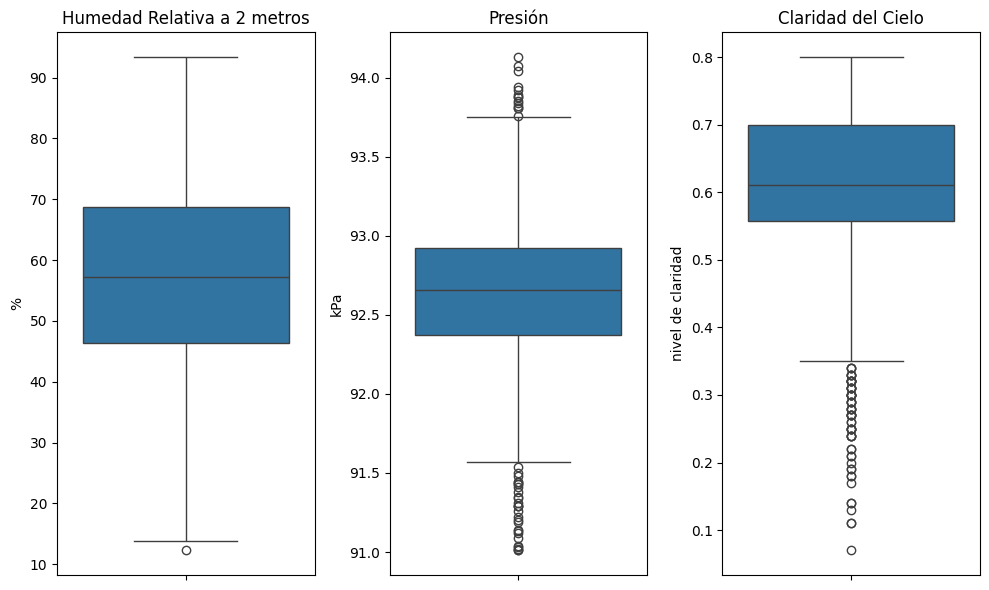

In [218]:
# Grafica de boxplot para cada humedad relativa, presion y claridad del cielo
import matplotlib.pyplot as plt
import seaborn as sns

columnas = df[['RH2M', 'PS', 'ALLSKY_KT']]
Nombres_columnas = ['Humedad Relativa a 2 metros', 'Presión', 'Claridad del Cielo']
Unidades = ['%', 'kPa', 'nivel de claridad']

plt.figure(figsize=(10, 6))
for i, columna in enumerate(columnas):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[columna])
    plt.title(Nombres_columnas[i])
    plt.ylabel(Unidades[i])
plt.tight_layout()

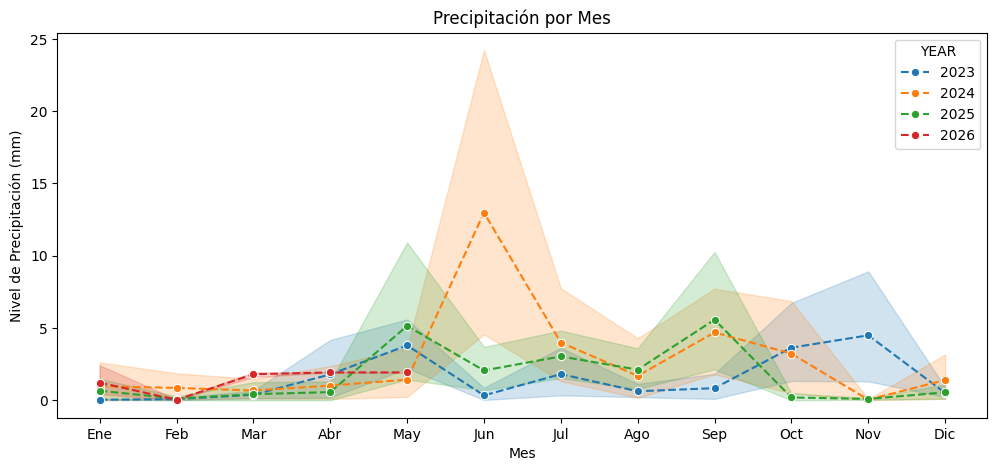

In [198]:
# Graficas de precipitación en funcion del mes y del año
plt.figure(figsize=(12, 5))
ax = sns.lineplot(x=df['MO'], y=df['IMERG_PRECTOT'], hue=df['YEAR'], marker='o', linestyle='--', palette='tab10')
plt.title('Precipitación por Mes')
plt.xlabel('Mes')
plt.xticks(df['MO'].unique())
ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.ylabel('Nivel de Precipitación (mm)')
plt.show()

## Limpieza de datos

In [199]:
# Se necesita normalizar los datos para que estén en la misma escala
# Se usara un modelo lineal para predecir la precipitación que es sensible a la escala de los datos
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# crearemos una copia del dataframe original para normalizar solo las columnas que no son la variable objetivo
columnas_a_normalizar = df.columns.difference(['MO', 'IMERG_PRECTOT', 'PRECTOTCORR', 'YEAR', 'DY'])
df_normalizado = df.copy()
df_normalizado[columnas_a_normalizar] = scaler.fit_transform(df[columnas_a_normalizar])
df_normalizado.head()

,YEAR,MO,DY,RH2M,PS,T2MDEW,QV2M,T2M,ALLSKY_KT,T2MWET,WS10M,WD10M,IMERG_PRECTOT,PRECTOTCORR
0,2023,1,1,-0.935450,-0.232966,-0.973905,-1.065679,-0.540167,0.811620,-0.849532,-0.415697,1.037900,0.0,0.0
1,2023,1,2,-0.734134,-0.976856,-0.794508,-0.926723,-0.388727,0.188423,-0.667129,-0.177221,1.138676,0.0,0.0
2,2023,1,3,-1.394399,-0.700554,-1.334158,-1.303167,-0.503612,1.123218,-1.047569,1.210277,1.697327,0.0,0.0
3,2023,1,4,-1.461720,0.468416,-1.440630,-1.373908,-0.721198,0.967419,-1.217812,-0.914329,-0.953529,0.0,0.0
4,2023,1,5,-0.673933,1.318576,-0.908272,-1.055573,-0.836083,1.045319,-0.957236,-0.805931,-0.065164,0.0,0.0


In [200]:
# Se eliminarán los datos de las año y dia para evitar que el modelo se sobreajuste a patrones temporales específicos
df_normalizado = df_normalizado.drop(columns=['YEAR', 'DY'])
df_normalizado.head()

# La columna de mes se mantendrá con cambios para que el modelo pueda aprender patrones estacionales
# Transformamos los meses con codificación ciclica usando funciones seno y coseno
import numpy as np
df_normalizado['MO_SIN'] = np.sin(2 * np.pi * df['MO'] / 12)
df_normalizado['MO_COS'] = np.cos(2 * np.pi * df['MO'] / 12)
df_normalizado = df_normalizado.drop(columns=['MO'])
df_normalizado.head()

,RH2M,PS,T2MDEW,QV2M,T2M,ALLSKY_KT,T2MWET,WS10M,WD10M,IMERG_PRECTOT,PRECTOTCORR,MO_SIN,MO_COS
0,-0.935450,-0.232966,-0.973905,-1.065679,-0.540167,0.811620,-0.849532,-0.415697,1.037900,0.0,0.0,0.5,0.866025
1,-0.734134,-0.976856,-0.794508,-0.926723,-0.388727,0.188423,-0.667129,-0.177221,1.138676,0.0,0.0,0.5,0.866025
2,-1.394399,-0.700554,-1.334158,-1.303167,-0.503612,1.123218,-1.047569,1.210277,1.697327,0.0,0.0,0.5,0.866025
3,-1.461720,0.468416,-1.440630,-1.373908,-0.721198,0.967419,-1.217812,-0.914329,-0.953529,0.0,0.0,0.5,0.866025
4,-0.673933,1.318576,-0.908272,-1.055573,-0.836083,1.045319,-0.957236,-0.805931,-0.065164,0.0,0.0,0.5,0.866025


## Preparación del modelo

In [201]:
# Modelo de regresión lineal para predecir la precipitación usando las variables objetivo IMERG_PRECTOT y PRECTOTCORR

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Selección de características y las variables objetivo
y = df_normalizado[['IMERG_PRECTOT', 'PRECTOTCORR']]
X = df_normalizado.drop(['IMERG_PRECTOT', 'PRECTOTCORR'], axis=1)

# División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# Antes de entrenar, se aplicara transformación logarítmica a las variables objetivo para manejar mejor la distribución sesgada de los datos de precipitación
y_train_log = np.log1p(y_train)  # log1p apliga log(1 + x) para evitar problemas con valores de cero
y_test_log = np.log1p(y_test)

# Creación y entrenamiento del modelo de regresión lineal
# (scikit ya puede manejar múltiples variables objetivo por defecto)
model = LinearRegression()

Resultados para IMERG_PRECTOT:
Mean Squared Error: 38.72613248334939
R^2 Score: 0.22975992297402315

Resultados para PRECTOTCORR:
Mean Squared Error: 12.666421909290301
R^2 Score: 0.5128441394064925


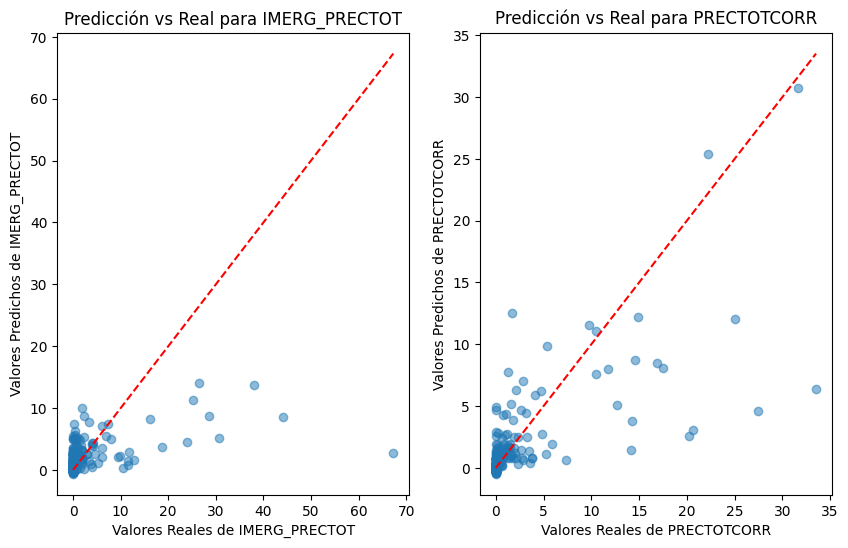

In [202]:
# transformacion polinomial
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# prediccion del modelo, con pesos aplicados
weights = np.where(y_train['IMERG_PRECTOT'] > 0.8, 9, 1)
model.fit(X_train_poly, y_train_log, sample_weight=weights)
y_pred_log = model.predict(X_test_poly)

# regresamos a la escala original aplicando la función inversa de log1p
y_pred = np.expm1(y_pred_log)  # expm1 aplica exp(x) - 1 para revertir la transformación logarítmica

#resultados para prediccion de imerg
mse_imerg = mean_squared_error(y_test['IMERG_PRECTOT'], y_pred[:, 0])
r2_imerg = r2_score(y_test['IMERG_PRECTOT'], y_pred[:, 0])
print(f"Resultados para IMERG_PRECTOT:")
print(f"Mean Squared Error: {mse_imerg}")
print(f"R^2 Score: {r2_imerg}")

#resultados para prediccion de prectotcorr
mse_prectotcorr = mean_squared_error(y_test['PRECTOTCORR'], y_pred[:, 1])
r2_prectotcorr = r2_score(y_test['PRECTOTCORR'], y_pred[:, 1])
print(f"\nResultados para PRECTOTCORR:")
print(f"Mean Squared Error: {mse_prectotcorr}")
print(f"R^2 Score: {r2_prectotcorr}")

# resultados predichos vs reales para IMERG_PRECTOT
y_test_imerg = y_test['IMERG_PRECTOT'].values
y_pred_imerg = y_pred[:, 0]

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test_imerg, y_pred_imerg, alpha=0.5)
plt.plot([y_test_imerg.min(), y_test_imerg.max()], [y_test_imerg.min(), y_test_imerg.max()], 'r--')
plt.xlabel('Valores Reales de IMERG_PRECTOT')
plt.ylabel('Valores Predichos de IMERG_PRECTOT')
plt.title('Predicción vs Real para IMERG_PRECTOT')

# resultados predichos vs reales para PRECTOTCORR
y_test_prectotcorr = y_test['PRECTOTCORR'].values
y_pred_prectotcorr = y_pred[:, 1]

plt.subplot(1, 2, 2)
plt.scatter(y_test_prectotcorr, y_pred_prectotcorr, alpha=0.5)
plt.plot([y_test_prectotcorr.min(), y_test_prectotcorr.max()], [y_test_prectotcorr.min(), y_test_prectotcorr.max()], 'r--')
plt.xlabel('Valores Reales de PRECTOTCORR')
plt.ylabel('Valores Predichos de PRECTOTCORR')
plt.title('Predicción vs Real para PRECTOTCORR')
plt.show()


In [224]:
# imprimir los dias de mayo donde llovera mas de 10 mm segun el modelo

# tomamos los ultimos 16 dias de mayo del conjunto de prueba (dias 1 - 16)
mayo_test = df_normalizado[-17:-1].drop(columns=['IMERG_PRECTOT', 'PRECTOTCORR'])

# predecimos la precipitación para estos días
mayo_test_poly = poly.transform(mayo_test)
mayo_pred_log = model.predict(mayo_test_poly)
mayo_pred = np.expm1(mayo_pred_log)

print("predicciones de precipitación para los dias 1 - 16 de mayo (IMERG) vs datos reales:")
for i in range(len(mayo_pred)):
    texto_1 = f"dia {i+1}: {mayo_pred[i][0].item():.2f}mm"
    texto_2 = f"dia {i+1}: {df.iloc[-16+i]['PRECTOTCORR']:.2f}mm"
    print(texto_1 + " \t\t|\t " + texto_2)


predicciones de precipitación para los dias 1 - 16 de mayo (IMERG) vs datos reales:
dia 1: 2.34mm 		|	 dia 1: 5.32mm
dia 2: 1.81mm 		|	 dia 2: 4.65mm
dia 3: 2.45mm 		|	 dia 3: 0.73mm
dia 4: 1.46mm 		|	 dia 4: 0.55mm
dia 5: 1.77mm 		|	 dia 5: 0.47mm
dia 6: 1.79mm 		|	 dia 6: 1.71mm
dia 7: 2.73mm 		|	 dia 7: 11.78mm
dia 8: 1.70mm 		|	 dia 8: 27.05mm
dia 9: 1.44mm 		|	 dia 9: 4.57mm
dia 10: 1.55mm 		|	 dia 10: 1.35mm
dia 11: 1.59mm 		|	 dia 11: 10.29mm
dia 12: 1.99mm 		|	 dia 12: 0.95mm
dia 13: 2.43mm 		|	 dia 13: 0.00mm
dia 14: 2.14mm 		|	 dia 14: 0.00mm
dia 15: 1.47mm 		|	 dia 15: 0.00mm
dia 16: 1.48mm 		|	 dia 16: 0.90mm


In [206]:
# prueba con random forest regressor
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)


df_rf = df.copy()
df_rf = df_rf.drop(columns=['YEAR', 'DY'])

#convertir los datos de precipitacion en datos binarios de lluvia o no lluvia, con un umbral de 0.5 mm
df_rf['IMERG_PRECTOT'] = (df_rf['IMERG_PRECTOT'] > 0.5).astype(int)
df_rf['PRECTOTCORR'] = (df_rf['PRECTOTCORR'] > 0.5).astype(int)

x = df_rf.drop(columns=['IMERG_PRECTOT', 'PRECTOTCORR'])
y = df_rf[['IMERG_PRECTOT', 'PRECTOTCORR']]

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(x, y, test_size=0.2, random_state=10)
model_rf.fit(X_train_rf, y_train_rf)
y_pred_rf = model_rf.predict(X_test_rf)

In [214]:
# matriz de confusion y reporte de clasificación para IMERG_PRECTOT
from sklearn.metrics import confusion_matrix, classification_report
y_test_imerg_rf = y_test_rf['IMERG_PRECTOT']
y_pred_imerg_rf = (y_pred_rf[:, 0] > 0.5).astype(int)
print("Matriz de Confusión para IMERG_PRECTOT:")
print(confusion_matrix(y_test_imerg_rf, y_pred_imerg_rf))
print("\nReporte de Clasificación para IMERG_PRECTOT:")
print(classification_report(y_test_imerg_rf, y_pred_imerg_rf))

Matriz de Confusión para IMERG_PRECTOT:
[[167  13]
 [ 32  35]]

Reporte de Clasificación para IMERG_PRECTOT:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       180
           1       0.73      0.52      0.61        67

    accuracy                           0.82       247
   macro avg       0.78      0.73      0.74       247
weighted avg       0.81      0.82      0.81       247

